8.Wine Quality Analysis and k-NN Classification

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

a) Perform Exploratory Data Analysis (EDA):
• Display the first five records.
• Check for missing values.
• Display descriptive statistics.
• Display the distribution of wine quality.

In [5]:
# Read the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WineQT.csv")
# Display first five records
print("First five records:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())

# Display distribution of wine quality
print("\nDistribution of wine quality:")
print(df["quality"].value_counts().sort_index())

First five records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8    

b) Visualize the data using:
• Scatter plot of alcohol vs. pH.
• Histogram of alcohol.
• Box plot of alcohol grouped by quality.

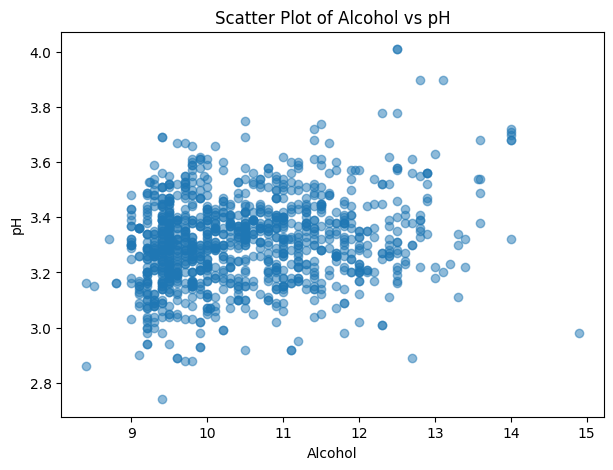

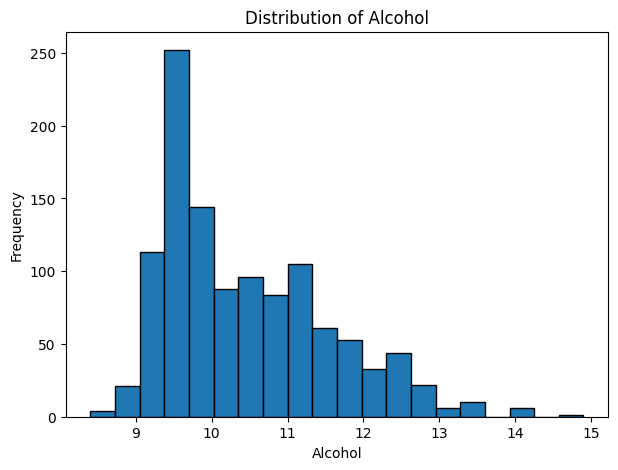

<Figure size 800x500 with 0 Axes>

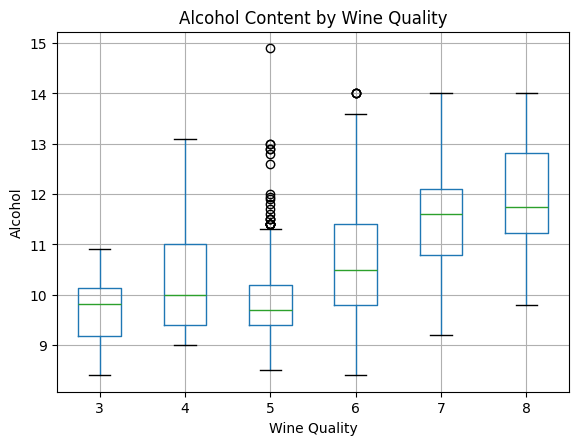

In [10]:
# 1. Scatter plot of alcohol vs pH
plt.figure(figsize=(7, 5))
plt.scatter(df["alcohol"], df["pH"], alpha=0.5)
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.title("Scatter Plot of Alcohol vs pH")
plt.show()

# 2. Histogram of alcohol
plt.figure(figsize=(7, 5))
plt.hist(df["alcohol"], bins=20, edgecolor="black")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.title("Distribution of Alcohol")
plt.show()

# 3. Box plot of alcohol grouped by quality
plt.figure(figsize=(8, 5))
df.boxplot(column="alcohol", by="quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.title("Alcohol Content by Wine Quality")
plt.suptitle("")
plt.show()

c) Implement k-NN Classification:
• Remove missing values and prepare features and target.
• Split the data into 80% training and 20% testing sets.
• Standardize the features using StandardScaler.
• Apply k-NN with different values of k and display the accuracy.

• Allow the user to enter k values and display the corresponding accuracy.

In [7]:
# Remove missing values
df = df.dropna()

# Prepare features and target
X = df.drop("quality", axis=1)
y = df["quality"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
print("\nAccuracy for different k values:")
k_values = [3, 5, 7, 9, 11]
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("k =", k, "Accuracy =", round(accuracy * 100, 2), "%")


Accuracy for different k values:
k = 3 Accuracy = 56.77 %
k = 5 Accuracy = 57.64 %
k = 7 Accuracy = 63.32 %
k = 9 Accuracy = 60.7 %
k = 11 Accuracy = 60.7 %


In [9]:
k = int(input("\nEnter the value of k: "))
if k <= 0:
    print("Please enter a positive value of k.")
else:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy for k =", k, "is",
          round(accuracy * 100, 2), "%")


Enter the value of k: 5
Accuracy for k = 5 is 57.64 %
